# Import needed module 導入需要的模組

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
import plotly.express as px

# Data prepare 資料準備

import needed dataset導入需要的資料集

In [2]:
import requests, zipfile, io, os

base_url = "https://divvy-tripdata.s3.amazonaws.com/"
months = [
    ("202301", "jan_2023"), ("202302", "feb_2023"), ("202303", "mar_2023"),
    ("202304", "apr_2023"), ("202305", "may_2023"), ("202306", "jun_2023"),
    ("202307", "jul_2023"), ("202308", "aug_2023"), ("202309", "sep_2023"),
    ("202310", "oct_2023"), ("202311", "nov_2023"), ("202312", "dec_2023"),
]

os.makedirs("divvy_data", exist_ok=True)
dfs = {}

for ym, varname in months:
    csv_name = f"divvy_data/{ym}-divvy-tripdata.csv"
    if not os.path.exists(csv_name):
        url = base_url + f"{ym}-divvy-tripdata.zip"
        print(f"Downloading {url} ...")
        r = requests.get(url)
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall("divvy_data")
    dfs[varname] = pd.read_csv(csv_name)
    print(f"Loaded {varname}: {dfs[varname].shape}")

jan_2023 = dfs["jan_2023"]
feb_2023 = dfs["feb_2023"]
mar_2023 = dfs["mar_2023"]
apr_2023 = dfs["apr_2023"]
may_2023 = dfs["may_2023"]
jun_2023 = dfs["jun_2023"]
jul_2023 = dfs["jul_2023"]
aug_2023 = dfs["aug_2023"]
sep_2023 = dfs["sep_2023"]
oct_2023 = dfs["oct_2023"]
nov_2023 = dfs["nov_2023"]
dec_2023 = dfs["dec_2023"]


set up combine dataset設定組合資料集

In [ ]:
data = pd.concat([jan_2023,feb_2023,mar_2023,apr_2023,may_2023,
                  jun_2023,jul_2023,aug_2023,sep_2023,oct_2023,nov_2023,dec_2023],
                 ignore_index = True)
data.info()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5719877 entries, 0 to 5719876
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 567.3+ MB


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,F96D5A74A3E41399,electric_bike,2023-01-21 20:05:42,2023-01-21 20:16:33,Lincoln Ave & Fullerton Ave,TA1309000058,Hampden Ct & Diversey Ave,202480.0,41.924074,-87.646278,41.930000,-87.640000,member
1,13CB7EB698CEDB88,classic_bike,2023-01-10 15:37:36,2023-01-10 15:46:05,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member
2,BD88A2E670661CE5,electric_bike,2023-01-02 07:51:57,2023-01-02 08:05:11,Western Ave & Lunt Ave,RP-005,Valli Produce - Evanston Plaza,599,42.008571,-87.690483,42.039742,-87.699413,casual
3,C90792D034FED968,classic_bike,2023-01-22 10:52:58,2023-01-22 11:01:44,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member
4,3397017529188E8A,classic_bike,2023-01-12 13:58:01,2023-01-12 14:13:20,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5719872,F74DF9549B504A6B,electric_bike,2023-12-07 13:15:24,2023-12-07 13:17:37,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874702,-87.649804,41.874640,-87.657030,casual
5719873,BCDA66E761CC1029,classic_bike,2023-12-08 18:42:21,2023-12-08 18:45:56,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874754,-87.649807,41.874640,-87.657030,casual
5719874,D2CF330F9C266683,classic_bike,2023-12-05 14:09:11,2023-12-05 14:13:01,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874754,-87.649807,41.874640,-87.657030,member
5719875,3829A0D1E00EE970,electric_bike,2023-12-02 21:36:07,2023-12-02 21:53:45,Damen Ave & Madison St,13134,Morgan St & Lake St*,chargingstx4,41.881396,-87.674984,41.885492,-87.652289,casual


Data Cleaning and Manipulating Process 資料清理和操作過程


In [ ]:
# Checking the null values and counting with the sum() function
# 檢查空值並使用 sum() 函數進行計數
data.isna().sum()

ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_station_name    875716
start_station_id      875848
end_station_name      929202
end_station_id        929343
start_lat                  0
start_lng                  0
end_lat                 6990
end_lng                 6990
member_casual              0
dtype: int64

Dropping null values刪除空值

In [ ]:
data.dropna(inplace= True)
data.isna().sum()

ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat               0
end_lng               0
member_casual         0
dtype: int64

Converting datatype of "started_at" & "ended_at" columns to "datetime64" type.
將“started_at”和“ending_at”列的資料類型轉換為“datetime64”類型。

In [ ]:
data['started_at'] = pd.to_datetime(data['started_at'])
data['ended_at'] = pd.to_datetime(data['ended_at'])

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4331707 entries, 0 to 5719876
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
dtypes: datetime64[ns](2), float64(4), object(7)
memory usage: 462.7+ MB


Creating New Column "ride_length" and changing its datatype to "int32"
建立新列“ride_length”並將其資料類型變更為“int32”

In [ ]:
# In this column, each row contains the difference between "started_at and "ended_at" columns in minutes.
data['ride_length'] = (data['ended_at'] - data['started_at'])/pd.Timedelta(minutes=1)
data['ride_length'] = data['ride_length'].astype('int32')

data.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length
0,F96D5A74A3E41399,electric_bike,2023-01-21 20:05:42,2023-01-21 20:16:33,Lincoln Ave & Fullerton Ave,TA1309000058,Hampden Ct & Diversey Ave,202480.0,41.924074,-87.646278,41.930000,-87.640000,member,10
1,13CB7EB698CEDB88,classic_bike,2023-01-10 15:37:36,2023-01-10 15:46:05,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,8
2,BD88A2E670661CE5,electric_bike,2023-01-02 07:51:57,2023-01-02 08:05:11,Western Ave & Lunt Ave,RP-005,Valli Produce - Evanston Plaza,599,42.008571,-87.690483,42.039742,-87.699413,casual,13
3,C90792D034FED968,classic_bike,2023-01-22 10:52:58,2023-01-22 11:01:44,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,8
4,3397017529188E8A,classic_bike,2023-01-12 13:58:01,2023-01-12 14:13:20,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,15


Sorting Values by "ride_length" column in Ascending orde
按“ride_length”欄位以升序對數值進行排序

In [ ]:
data.sort_values(by = 'ride_length')

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length
5452383,5C5FCC49C148635F,classic_bike,2023-11-05 01:55:47,2023-11-05 01:01:13,Halsted St & Wrightwood Ave,TA1309000061,Halsted St & Roscoe St,TA1309000025,41.929143,-87.649077,41.943670,-87.648950,member,-54
5415699,D17C0701A2AC27A8,classic_bike,2023-11-05 01:53:49,2023-11-05 01:00:41,Halsted St & Wrightwood Ave,TA1309000061,Sedgwick St & Webster Ave,13191,41.929143,-87.649077,41.922167,-87.638888,member,-53
5433976,274EDE47C11F43AF,classic_bike,2023-11-05 01:55:51,2023-11-05 01:02:37,Southport Ave & Wellington Ave,TA1307000006,Southport Ave & Wrightwood Ave,TA1307000113,41.935775,-87.663600,41.928773,-87.663913,casual,-53
5257025,0AF3917F317F4C5F,classic_bike,2023-11-05 01:54:43,2023-11-05 01:01:31,Halsted St & 21st St,13162,Racine Ave & 18th St,13164,41.853780,-87.646603,41.858166,-87.656495,casual,-53
5212240,FBDEF92A65F125D9,classic_bike,2023-11-05 01:58:37,2023-11-05 01:05:42,LaSalle Dr & Huron St,KP1705001026,Clark St & Elm St,TA1307000039,41.894877,-87.632326,41.902973,-87.631280,casual,-52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2102616,3BC5FFFDF7503DAA,docked_bike,2023-06-15 13:28:59,2023-06-18 23:12:06,DuSable Lake Shore Dr & Monroe St,13300,Fort Dearborn Dr & 31st St*,chargingstx06,41.880958,-87.616743,41.838676,-87.608832,casual,4903
3229464,4031082BC503CC84,docked_bike,2023-08-02 17:28:57,2023-08-06 11:07:57,University Ave & 57th St,KA1503000071,Museum of Science and Industry,KA1503000074,41.791478,-87.599861,41.791728,-87.583945,casual,5379
3432392,47158A16C754A9F4,docked_bike,2023-08-10 22:17:49,2023-08-15 17:09:02,Larrabee St & Webster Ave,13193,Michigan Ave & Oak St,13042,41.921822,-87.644140,41.900960,-87.623777,casual,6891
2104833,FA287922CA358CE0,docked_bike,2023-06-03 17:52:15,2023-06-11 11:44:31,Fort Dearborn Dr & 31st St,TA1307000048,Fort Dearborn Dr & 31st St*,chargingstx06,41.838556,-87.608218,41.838676,-87.608832,casual,11152


Removing rows containing negative values
刪除包含負值的行

In [ ]:
data = data[data['ride_length'] > 0]
data = data.reset_index()
data = data.drop(columns=['index'])
 
data

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length
0,F96D5A74A3E41399,electric_bike,2023-01-21 20:05:42,2023-01-21 20:16:33,Lincoln Ave & Fullerton Ave,TA1309000058,Hampden Ct & Diversey Ave,202480.0,41.924074,-87.646278,41.930000,-87.640000,member,10
1,13CB7EB698CEDB88,classic_bike,2023-01-10 15:37:36,2023-01-10 15:46:05,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,8
2,BD88A2E670661CE5,electric_bike,2023-01-02 07:51:57,2023-01-02 08:05:11,Western Ave & Lunt Ave,RP-005,Valli Produce - Evanston Plaza,599,42.008571,-87.690483,42.039742,-87.699413,casual,13
3,C90792D034FED968,classic_bike,2023-01-22 10:52:58,2023-01-22 11:01:44,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,8
4,3397017529188E8A,classic_bike,2023-01-12 13:58:01,2023-01-12 14:13:20,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4244184,F74DF9549B504A6B,electric_bike,2023-12-07 13:15:24,2023-12-07 13:17:37,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874702,-87.649804,41.874640,-87.657030,casual,2
4244185,BCDA66E761CC1029,classic_bike,2023-12-08 18:42:21,2023-12-08 18:45:56,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874754,-87.649807,41.874640,-87.657030,casual,3
4244186,D2CF330F9C266683,classic_bike,2023-12-05 14:09:11,2023-12-05 14:13:01,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874754,-87.649807,41.874640,-87.657030,member,3
4244187,3829A0D1E00EE970,electric_bike,2023-12-02 21:36:07,2023-12-02 21:53:45,Damen Ave & Madison St,13134,Morgan St & Lake St*,chargingstx4,41.881396,-87.674984,41.885492,-87.652289,casual,17


Using the dt.day_name() to get the name of the day to each date
使用 dt.day_name() 取得每個日期的日期名稱

In [ ]:
data["started_at"].dt.day_name()

0          Saturday
1           Tuesday
2            Monday
3            Sunday
4          Thursday
             ...   
4244184    Thursday
4244185      Friday
4244186     Tuesday
4244187    Saturday
4244188      Monday
Name: started_at, Length: 4244189, dtype: object

In [ ]:
# df['month_of_date'] = df['date_given'].dt.month
data["started_at"].dt.month

0           1
1           1
2           1
3           1
4           1
           ..
4244184    12
4244185    12
4244186    12
4244187    12
4244188    12
Name: started_at, Length: 4244189, dtype: int32

Using the dt.month_name to see the months of each date
使用 dt.month_name 查看每個日期的月份

In [ ]:
# later assign it into a new column
data["started_at"].dt.month_name()

0           January
1           January
2           January
3           January
4           January
             ...   
4244184    December
4244185    December
4244186    December
4244187    December
4244188    December
Name: started_at, Length: 4244189, dtype: object

Extracting the specific day提取特定日期

In [ ]:
data["started_at"].dt.day

0          21
1          10
2           2
3          22
4          12
           ..
4244184     7
4244185     8
4244186     5
4244187     2
4244188    11
Name: started_at, Length: 4244189, dtype: int32

Now taking the year this "dt." is kind a library to manipulate date
現在以年份為「dt」。是一個操縱日期的庫

In [ ]:
data["started_at"].dt.year

0          2023
1          2023
2          2023
3          2023
4          2023
           ... 
4244184    2023
4244185    2023
4244186    2023
4244187    2023
4244188    2023
Name: started_at, Length: 4244189, dtype: int32

Create and insert new columns
建立並插入新列

In [ ]:
data["weekday"] = data["started_at"].dt.day_name()
data["day"] = data["started_at"].dt.day
data["month"] = data["started_at"].dt.month
data["month_name"] = data["started_at"].dt.month_name()
data["year"] = data["started_at"].dt.year

data

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,weekday,day,month,month_name,year
0,F96D5A74A3E41399,electric_bike,2023-01-21 20:05:42,2023-01-21 20:16:33,Lincoln Ave & Fullerton Ave,TA1309000058,Hampden Ct & Diversey Ave,202480.0,41.924074,-87.646278,41.930000,-87.640000,member,10,Saturday,21,1,January,2023
1,13CB7EB698CEDB88,classic_bike,2023-01-10 15:37:36,2023-01-10 15:46:05,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,8,Tuesday,10,1,January,2023
2,BD88A2E670661CE5,electric_bike,2023-01-02 07:51:57,2023-01-02 08:05:11,Western Ave & Lunt Ave,RP-005,Valli Produce - Evanston Plaza,599,42.008571,-87.690483,42.039742,-87.699413,casual,13,Monday,2,1,January,2023
3,C90792D034FED968,classic_bike,2023-01-22 10:52:58,2023-01-22 11:01:44,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,8,Sunday,22,1,January,2023
4,3397017529188E8A,classic_bike,2023-01-12 13:58:01,2023-01-12 14:13:20,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,15,Thursday,12,1,January,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4244184,F74DF9549B504A6B,electric_bike,2023-12-07 13:15:24,2023-12-07 13:17:37,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874702,-87.649804,41.874640,-87.657030,casual,2,Thursday,7,12,December,2023
4244185,BCDA66E761CC1029,classic_bike,2023-12-08 18:42:21,2023-12-08 18:45:56,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874754,-87.649807,41.874640,-87.657030,casual,3,Friday,8,12,December,2023
4244186,D2CF330F9C266683,classic_bike,2023-12-05 14:09:11,2023-12-05 14:13:01,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874754,-87.649807,41.874640,-87.657030,member,3,Tuesday,5,12,December,2023
4244187,3829A0D1E00EE970,electric_bike,2023-12-02 21:36:07,2023-12-02 21:53:45,Damen Ave & Madison St,13134,Morgan St & Lake St*,chargingstx4,41.881396,-87.674984,41.885492,-87.652289,casual,17,Saturday,2,12,December,2023


Checking the number of unique values for each column.
檢查每列的唯一值的數量。

In [ ]:
data.nunique()

ride_id               4244189
rideable_type               3
started_at            3722350
ended_at              3733231
start_station_name       1518
start_station_id         1453
end_station_name         1548
end_station_id           1476
start_lat              679019
start_lng              644661
end_lat                  9341
end_lng                  9408
member_casual               2
ride_length              1467
weekday                     7
day                        31
month                      12
month_name                 12
year                        1
dtype: int64

Using the duplicated() function combined with the sum() to have the total number of duplicated values
使用duplicate()函數結合sum()得到重複值的總數

In [ ]:
data["ride_id"].duplicated().sum()

0

export cleaned dataset
匯出清理後的資料集

In [ ]:
data_cleaned = data

In [ ]:
# df.to_csv("your_name.csv")
data_cleaned.to_csv("data_clean.csv")

# Data analysis english數據分析英文

In [ ]:
import duckdb

# 將清理後的 DataFrame 註冊至 DuckDB，後續分析改用 SQL
conn = duckdb.connect()
conn.register("rides", data_cleaned)
print(f"✓ DuckDB ready — rides 資料表已載入 {len(data_cleaned):,} 筆")

Percentage of total users
佔總用戶的百分比

In [ ]:
percent_df = conn.execute("""
    SELECT
        member_casual,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM rides
    GROUP BY member_casual
""").df()

percent = percent_df.set_index('member_casual')['pct']
percent

fix the days of the week that are out of order
修復一週中不按順序排列的日子。

In [17]:
day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
data_cleaned['weekday'] = pd.Categorical(data_cleaned['weekday'], categories=day_order, ordered=True)
data_cleaned

,Unnamed: 0,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,weekday,day,month,month_name,year
0,0,F96D5A74A3E41399,electric_bike,2023-01-21 20:05:42,2023-01-21 20:16:33,Lincoln Ave & Fullerton Ave,TA1309000058,Hampden Ct & Diversey Ave,202480.0,41.924074,-87.646278,41.930000,-87.640000,member,10,Saturday,21,1,January,2023
1,1,13CB7EB698CEDB88,classic_bike,2023-01-10 15:37:36,2023-01-10 15:46:05,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,8,Tuesday,10,1,January,2023
2,2,BD88A2E670661CE5,electric_bike,2023-01-02 07:51:57,2023-01-02 08:05:11,Western Ave & Lunt Ave,RP-005,Valli Produce - Evanston Plaza,599,42.008571,-87.690483,42.039742,-87.699413,casual,13,Monday,2,1,January,2023
3,3,C90792D034FED968,classic_bike,2023-01-22 10:52:58,2023-01-22 11:01:44,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,8,Sunday,22,1,January,2023
4,4,3397017529188E8A,classic_bike,2023-01-12 13:58:01,2023-01-12 14:13:20,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,15,Thursday,12,1,January,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4244184,4244184,F74DF9549B504A6B,electric_bike,2023-12-07 13:15:24,2023-12-07 13:17:37,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874702,-87.649804,41.874640,-87.657030,casual,2,Thursday,7,12,December,2023
4244185,4244185,BCDA66E761CC1029,classic_bike,2023-12-08 18:42:21,2023-12-08 18:45:56,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874754,-87.649807,41.874640,-87.657030,casual,3,Friday,8,12,December,2023
4244186,4244186,D2CF330F9C266683,classic_bike,2023-12-05 14:09:11,2023-12-05 14:13:01,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874754,-87.649807,41.874640,-87.657030,member,3,Tuesday,5,12,December,2023
4244187,4244187,3829A0D1E00EE970,electric_bike,2023-12-02 21:36:07,2023-12-02 21:53:45,Damen Ave & Madison St,13134,Morgan St & Lake St*,chargingstx4,41.881396,-87.674984,41.885492,-87.652289,casual,17,Saturday,2,12,December,2023


The average ride time by each day for members vs casual user
會員與休閒用戶每天的平均騎乘時間

In [ ]:
day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

data_cleaned_2 = conn.execute("""
    SELECT
        member_casual,
        weekday,
        AVG(ride_length) AS ride_length
    FROM rides
    GROUP BY member_casual, weekday
    ORDER BY member_casual,
             CASE weekday
                 WHEN 'Sunday'    THEN 0 WHEN 'Monday'    THEN 1 WHEN 'Tuesday'  THEN 2
                 WHEN 'Wednesday' THEN 3 WHEN 'Thursday'  THEN 4 WHEN 'Friday'   THEN 5
                 WHEN 'Saturday'  THEN 6
             END
""").df()
data_cleaned_2['weekday'] = pd.Categorical(data_cleaned_2['weekday'], categories=day_order, ordered=True)
data_cleaned_2

Analyse how casual and member use differently
分析休閒和會員的使用方式有何不同

In [ ]:
data_cleaned_1 = conn.execute("""
    SELECT member_casual, AVG(ride_length) AS ride_length
    FROM rides
    GROUP BY member_casual
    ORDER BY member_casual
""").df()
data_cleaned_1

各月份平均騎行時長 / Average ride length by month for members vs casual users

In [ ]:
data_cleaned_3 = conn.execute("""
    SELECT
        member_casual,
        month,
        month_name,
        AVG(ride_length) AS ride_length
    FROM rides
    GROUP BY member_casual, month, month_name
    ORDER BY member_casual, month
""").df()
data_cleaned_3

Count the rides, given both user, and bike type
根據使用者和自行車類型計算騎乘次數

In [ ]:
data_cleaned_4 = conn.execute("""
    SELECT
        member_casual,
        rideable_type,
        COUNT(ride_id) AS count
    FROM rides
    GROUP BY member_casual, rideable_type
    ORDER BY member_casual, rideable_type
""").df()
data_cleaned_4

no of ride by each month for members vs casual user
會員與休閒用戶每月的乘車次數

In [ ]:
data_cleaned_5 = conn.execute("""
    SELECT
        member_casual,
        month,
        month_name,
        COUNT(ride_id) AS ride_id
    FROM rides
    GROUP BY member_casual, month, month_name
    ORDER BY member_casual, month
""").df()
data_cleaned_5

尖峰時段分析 / Peak Hour Analysis

In [ ]:
peak_hours = conn.execute("""
    SELECT
        HOUR(started_at) AS hour,
        member_casual,
        COUNT(ride_id) AS ride_count
    FROM rides
    GROUP BY hour, member_casual
    ORDER BY hour
""").df()
peak_hours

In [ ]:
fig = plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='ride_count', hue='member_casual', data=peak_hours, marker='o')
plt.title('Ride Count by Hour of Day: Member vs Casual (2023)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Data visualization 數據視覺化

Visualize Percentage of Total Users
總用戶的百分比可視化

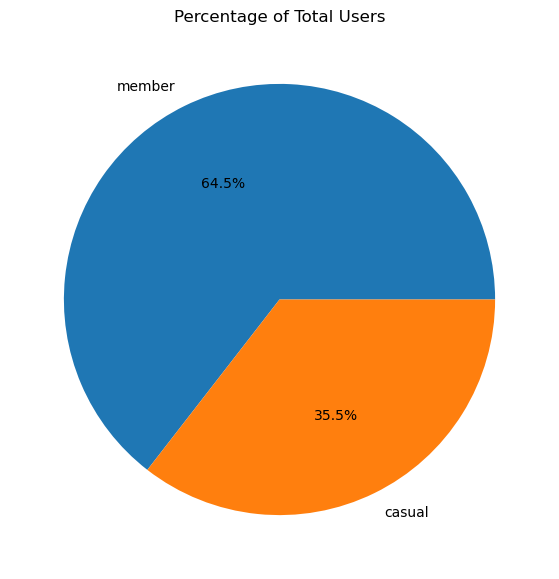

In [ ]:
member_casual = ['member', 'casual']
fig = plt.figure(figsize =(10, 7))
plt.pie(percent, labels = member_casual, autopct = "%0.1f%%")
plt.title("Percentage of Total Users")
plt.savefig('Percentage of Total Users', dpi=300, bbox_inches='tight')
plt.show()

Average Ride Length Member vs Casual in 2023
2023 年會員與休閒的平均騎乘長度

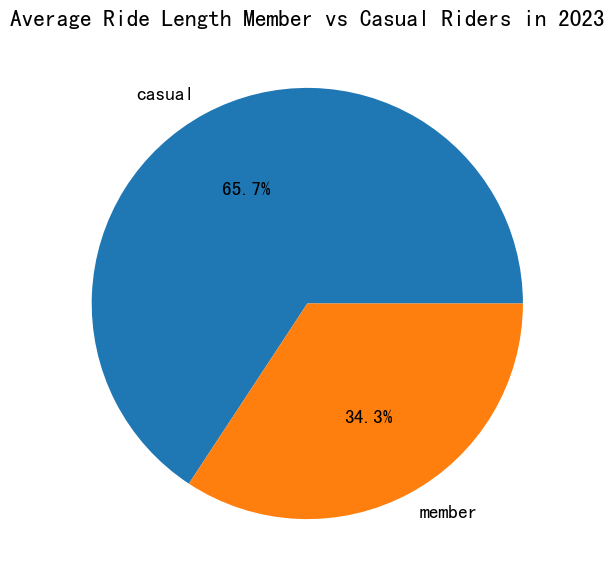

In [31]:
fig = plt.figure(figsize =(10, 7))
plt.pie(data_cleaned_1['ride_length'], labels = data_cleaned_1['member_casual'], autopct = "%0.1f%%")
plt.title("Average Ride Length Member vs Casual Riders in 2023")
plt.savefig('Average Ride Length Member vs Casual in 2023', dpi=300, bbox_inches='tight')
plt.show()

visualization for average duration
平均持續時間的可視化

c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


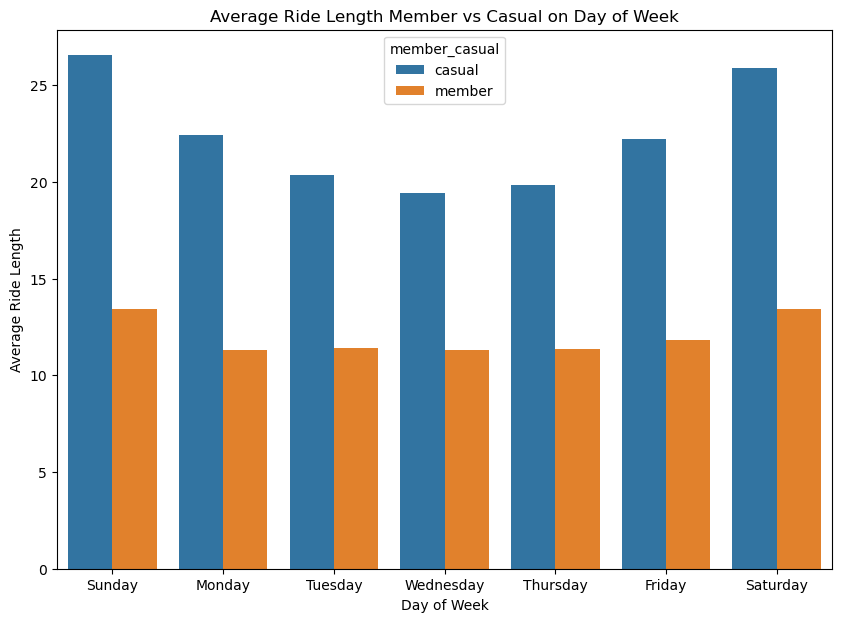

In [ ]:
fig = plt.figure(figsize =(10, 7))
sns.barplot(x='weekday', y='ride_length', hue = 'member_casual', data=data_cleaned_2)
plt.title("Average Ride Length Member vs Casual on Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Ride Length")
plt.savefig('Average Ride Length Member vs Casual on Day of Week.png', dpi=300)
plt.show()

Average Ride Length Member vs Casual on Month of Year
一年中月份會員與休閒會員的平均騎乘時長

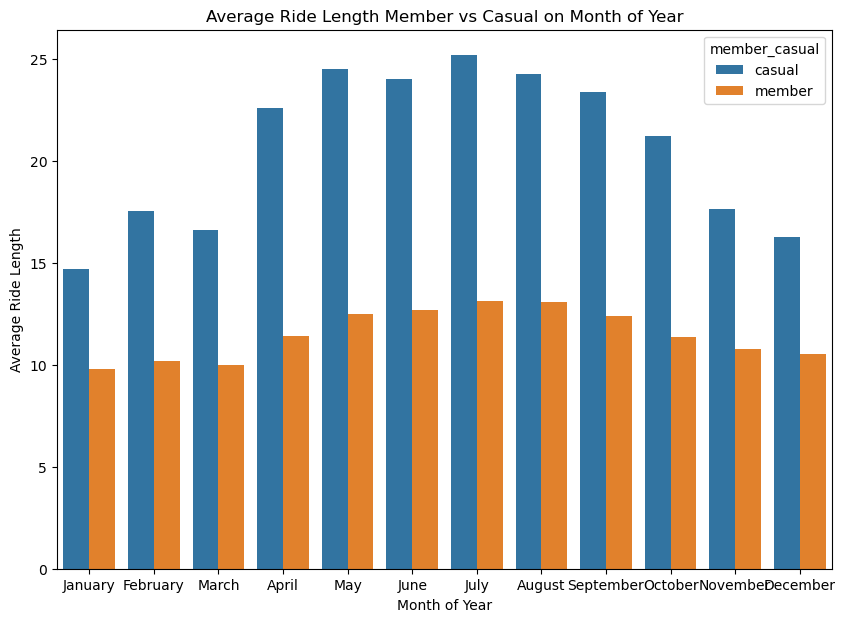

In [ ]:
fig = plt.figure(figsize =(10, 7))
sns.barplot(x='month_name', y='ride_length', hue = 'member_casual', data=data_cleaned_3)
plt.title("Average Ride Length Member vs Casual on Month of Year")
plt.xlabel("Month of Year")
plt.ylabel("Average Ride Length")
plt.savefig('Average Ride Length Member vs Casual on Month of Year.png', dpi=300)
plt.show()

Rideable types compare to riders
可騎乘類型與騎士的比較

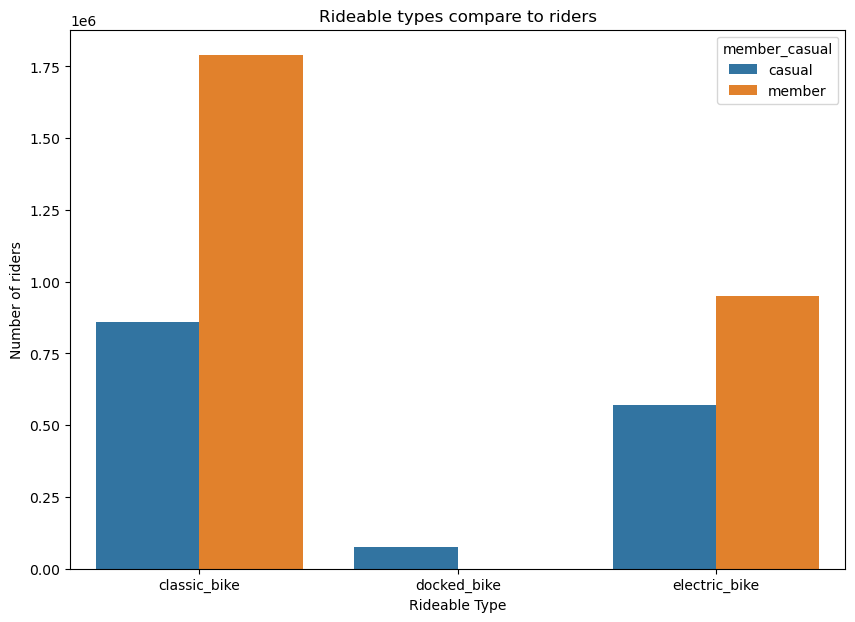

In [ ]:
fig = plt.figure(figsize =(10, 7))
sns.barplot(x='rideable_type', y='count', hue = 'member_casual', data=data_cleaned_4)
plt.title("Rideable types compare to riders")
plt.xlabel("Rideable Type")
plt.ylabel("Number of riders")
plt.savefig('Rideable types compare to riders.png', dpi=300)
plt.show()

c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 1200x1000 with 0 Axes>

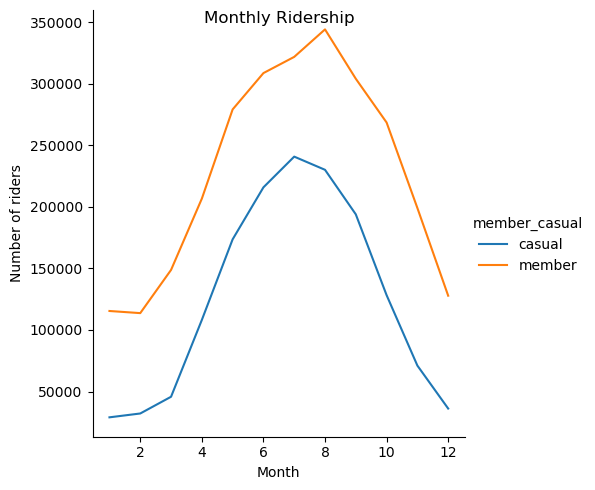

In [ ]:
fig = plt.figure(figsize =(12, 10))
sns.relplot(kind = 'line',x='month', y='ride_id', hue = 'member_casual', data=data_cleaned_5)
plt.title("Monthly Ridership", y = 0.95)
plt.xlabel("Month")
plt.ylabel("Number of riders")
plt.savefig('Monthly Ridership.png', dpi=250)
plt.show()

# Data analysis chinese數據分析中文

Percentage of total users
佔總用戶的百分比

In [36]:
data_cleaned['member_casual_chinese'] = data_cleaned['member_casual'].map({'member': '會員', 'casual': '臨時使用者'})
percent1 = round(data_cleaned["member_casual_chinese"].value_counts(normalize = True) * 100, 1)
percent1

member_casual_chinese
會員       64.5
臨時使用者    35.5
Name: proportion, dtype: float64

# Data visualization 數據視覺化

Visualize Percentage of Total Users
總用戶的百分比可視化

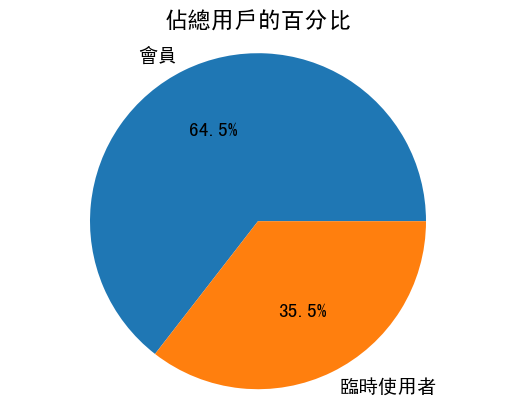

In [30]:
# Get data as lists (optional but useful for customization)
members = percent1['會員'].tolist()
casual_users = percent1['臨時使用者'].tolist()

# Set labels
labels = ['會員', '臨時使用者']

# Create the pie chart
plt.pie(percent1, labels=labels, autopct="%1.1f%%")
plt.title("佔總用戶的百分比")  # Set title in Chinese

# Optional: Customize the plot further
plt.axis('equal')  # Equal aspect ratio ensures a circular pie chart
plt.savefig('佔總用戶的百分比.png', dpi=300, bbox_inches='tight')
# Show the chart
plt.show()

Average Ride Length Member vs Casual in 2023
2023 年會員與休閒的平均騎乘長度

In [ ]:
mpl.rcParams['font.family'] = 'SimHei'
mpl.rcParams['font.size'] = 14

data_cleaned_1['member_casual_chinese'] = data_cleaned_1['member_casual'].map({'member': '會員', 'casual': '臨時使用者'})

fig, ax = plt.subplots(figsize=(8, 8))
plt.pie(data_cleaned_1['ride_length'], labels=data_cleaned_1['member_casual_chinese'], autopct="%0.1f%%", startangle=140)
plt.title("2023年會員與臨時使用者的平均騎行時長", fontsize=16)
plt.legend(data_cleaned_1['member_casual_chinese'], loc="upper left", title="會員類別", bbox_to_anchor=(1, 1))
plt.savefig('2023年會員與臨時使用者的平均騎行時長.png', dpi=300, bbox_inches='tight')
plt.show()

visualization for average duration
平均持續時間的可視化

c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


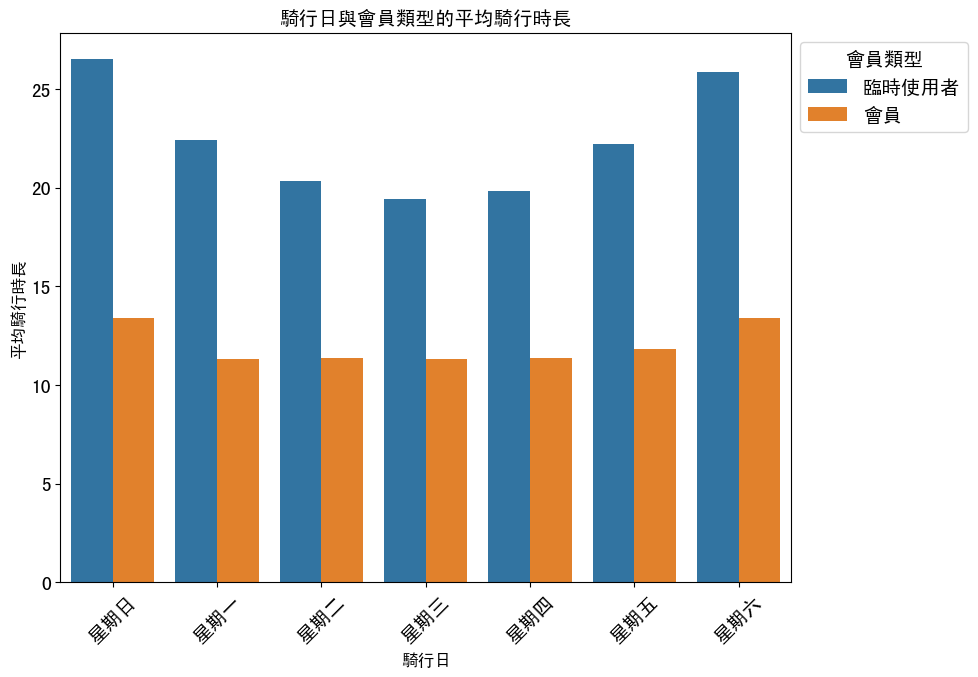

In [39]:

# Assuming data_cleaned_2 is as shown in the image (structure, not exact values)
# Define Traditional Chinese labels
member_casual_chinese = {'casual': '臨時使用者', 'member': '會員'}
weekday_chinese = {'Sunday': '星期日', 'Monday': '星期一', 'Tuesday': '星期二',
                   'Wednesday': '星期三', 'Thursday': '星期四', 'Friday': '星期五',
                   'Saturday': '星期六'}

data_cleaned_2['member_casual_chinese'] = data_cleaned_2['member_casual'].map(member_casual_chinese)
data_cleaned_2['weekday_chinese'] = data_cleaned_2['weekday'].map(weekday_chinese)

# Create the chart (assuming you want a bar chart)
fig, ax = plt.subplots(figsize=(10, 7))  # Adjust figure size as needed
sns.barplot(x='weekday_chinese', y='ride_length', hue='member_casual_chinese', data=data_cleaned_2)

# Set title, labels, and legend text in Traditional Chinese
plt.title("騎行日與會員類型的平均騎行時長", fontsize=14)  # Title: Average Ride Length...
plt.xlabel("騎行日", fontsize=12)  # X-axis label
plt.ylabel("平均騎行時長", fontsize=12)  # Y-axis label
plt.legend(title="會員類型", loc="upper left", bbox_to_anchor=(1, 1))  # Legend
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust spacing for better readability
plt.savefig('騎行日與會員類型的平均騎行時長.png', dpi=300, bbox_inches='tight')
plt.show()


Average Ride Length Member vs Casual on Month of Year
一年中月份會員與休閒會員的平均騎乘時長

In [ ]:
month_name_chinese = {1:'一月',2:'二月',3:'三月',4:'四月',5:'五月',6:'六月',
                      7:'七月',8:'八月',9:'九月',10:'十月',11:'十一月',12:'十二月'}
member_casual_chinese = {'casual':'臨時使用者','member':'會員'}
data_cleaned_3['month_name_chinese'] = data_cleaned_3['month'].map(month_name_chinese)
data_cleaned_3['member_casual_chinese'] = data_cleaned_3['member_casual'].map(member_casual_chinese)

fig = plt.figure(figsize=(10, 7))
sns.barplot(x='month_name_chinese', y='ride_length', hue='member_casual_chinese', data=data_cleaned_3)
plt.title("會員類別與月份的平均騎行時長", fontsize=14)
plt.xlabel("月份", fontsize=12)
plt.ylabel("平均騎行時長", fontsize=12)
plt.savefig('會員類別與月份的平均騎行時長.png', dpi=300)
plt.show()

Rideable types compare to riders
可騎乘類型與騎士的比較

In [ ]:
member_casual_chinese = {'casual':'臨時使用者','member':'會員'}
rideable_type_chinese = {'classic_bike':'普通自行車','electric_bike':'電動輔助自行車','docked_bike':'共享單車'}
data_cleaned_4['member_casual_chinese'] = data_cleaned_4['member_casual'].map(member_casual_chinese)
data_cleaned_4['rideable_type_chinese'] = data_cleaned_4['rideable_type'].map(rideable_type_chinese)

plt.figure(figsize=(8, 6))
sns.barplot(x='rideable_type_chinese', y='count', hue='member_casual_chinese', data=data_cleaned_4)
plt.title("會員類別與騎乘類型的騎乘次數", fontsize=14)
plt.xlabel("騎乘類型", fontsize=12)
plt.ylabel("騎乘次數", fontsize=12)
plt.legend(title="騎乘類型", loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('會員類別與騎乘類型的騎乘次數.png', dpi=300)
plt.show()

In [ ]:
mpl.rcParams['font.family'] = 'SimHei'
mpl.rcParams['font.size'] = 14

month_name_chinese = {1:'一月',2:'二月',3:'三月',4:'四月',5:'五月',6:'六月',
                      7:'七月',8:'八月',9:'九月',10:'十月',11:'十一月',12:'十二月'}
member_casual_chinese = {'casual':'臨時使用者','member':'會員'}
data_cleaned_5['month_name_chinese'] = data_cleaned_5['month'].map(month_name_chinese)
data_cleaned_5['member_casual_chinese'] = data_cleaned_5['member_casual'].map(member_casual_chinese)

plt.figure(figsize=(10, 6))
for member_type in data_cleaned_5['member_casual_chinese'].unique():
    df_f = data_cleaned_5[data_cleaned_5['member_casual_chinese'] == member_type]
    plt.plot(df_f['month_name_chinese'], df_f['ride_id'], label=member_type, marker='o')

plt.title("每月各會員類別的騎乘次數", fontsize=14)
plt.xlabel("月份", fontsize=12)
plt.ylabel("騎乘次數", fontsize=12)
plt.legend(title="會員類別", loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('每月各會員類別的騎乘次數.png', dpi=300)
plt.show()